## 1. Notebook Setup

This notebook evaluates whether different groups of county-year features improve vulnerability classification performance.

The goal is to test whether housing-market features alone are sufficient, or whether climate exposure, disaster history, socioeconomic/affordability indicators, NFIP insurance-loss variables, and spatial spillover features add meaningful predictive value.

This notebook uses the same vulnerability target created earlier:

- Low vulnerability
- Medium vulnerability
- High vulnerability

The main comparison uses one fixed model, Logistic Regression, across cumulative feature groups. This keeps the analysis focused on the contribution of feature layers rather than model choice.

In [1]:
# ==================================================
# Imports
# ==================================================

from pathlib import Path
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# Machine Learning Tools
# ==================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==================================================
# Project Paths
# ==================================================

PROJECT_ROOT = Path("..")

INTERIM_DATA = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "county_year_features"
)

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "feature_group_comparison"
)

RESULTS_FIGURES = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "feature_group_comparison"
)

RESULTS_LOGS = (
    PROJECT_ROOT
    / "results"
    / "logs"
)

RESULTS_MODELS = (
    PROJECT_ROOT
    / "results"
    / "models"
)

# ==================================================
# Input Dataset
# ==================================================

INPUT_DATA_PATH = (
    INTERIM_DATA
    / "county_year_vulnerability_scores.csv"
)

# ==================================================
# Output Folders
# ==================================================

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS_LOGS.mkdir(parents=True, exist_ok=True)
RESULTS_MODELS.mkdir(parents=True, exist_ok=True)

# ==================================================
# Project Settings
# ==================================================

PROJECT_START_YEAR = 2011
PROJECT_END_YEAR = 2025

TRAIN_END_YEAR = 2022
TEST_START_YEAR = 2023

RANDOM_STATE = 42

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Notebook setup complete.")
print(f"Input dataset: {INPUT_DATA_PATH}")
print(f"Results tables folder: {RESULTS_TABLES}")
print(f"Results figures folder: {RESULTS_FIGURES}")

Notebook setup complete.
Input dataset: ..\data\interim\county_year_features\county_year_vulnerability_scores.csv
Results tables folder: ..\results\tables\feature_group_comparison
Results figures folder: ..\results\figures\feature_group_comparison


## 2. Load Vulnerability-Ready Dataset

This notebook uses the vulnerability-ready county-year dataset created in the vulnerability score construction notebook.

The dataset already contains:

- raw county-year housing indicators
- FEMA climate exposure variables
- disaster history indicators
- ACS socioeconomic and affordability variables
- NFIP insurance-loss variables
- spatial spillover indicators
- vulnerability score and vulnerability class

For this notebook, the vulnerability score and sub-score columns are not used as predictors because they were used to construct the target.

In [2]:
# ==================================================
# Step 2: Load Vulnerability-Ready Dataset
# ==================================================

county_year_data = pd.read_csv(INPUT_DATA_PATH)

print("Vulnerability-ready dataset loaded successfully.")
print(f"Dataset shape: {county_year_data.shape}")

display(county_year_data.head())

Vulnerability-ready dataset loaded successfully.
Dataset shape: (1000, 123)


,STCOFIPS,RegionID,RegionName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,COUNTY,Year,avg_annual_housing_price,median_annual_housing_price,min_annual_housing_price,max_annual_housing_price,annual_price_volatility,monthly_observations,is_metro,SizeRank,POPULATION,CFLD_RISKS,HRCN_RISKS,SOVI_SCORE,RESL_SCORE,prev_year_housing_price,annual_price_growth_dollar,annual_price_growth_pct,baseline_housing_price,appreciation_from_baseline_pct,price_growth_acceleration,high_growth_flag,high_volatility_flag,complete_year_flag,neighbor_count,neighbor_avg_housing_price,neighbor_avg_price_growth_pct,neighbor_avg_price_volatility,neighbor_high_growth_share,neighbor_high_volatility_share,disaster_count,unique_disaster_events,climate_disaster_count,hurricane_disaster_count,tropical_storm_disaster_count,severe_storm_disaster_count,flood_disaster_count,fire_disaster_count,any_disaster_flag,any_climate_disaster_flag,cumulative_disaster_count,cumulative_climate_disaster_count,recent_3yr_disaster_count,recent_3yr_climate_disaster_count,acs_total_population,median_household_income,poverty_rate,unemployment_rate,owner_occupied_share,renter_occupied_share,median_gross_rent,acs_median_home_value,price_to_income_ratio,acs_estimated_2025_flag,nfip_claim_count,nfip_policy_count_sum,nfip_total_building_payment,nfip_total_contents_payment,nfip_total_icc_payment,nfip_total_claim_payment,nfip_avg_claim_payment,nfip_total_building_coverage,nfip_total_contents_coverage,nfip_cumulative_claim_count,nfip_cumulative_claim_payment,nfip_recent_3yr_claim_count,nfip_recent_3yr_claim_payment,nfip_claim_year_indicator,log_annual_price_volatility,log_price_to_income_ratio,log_median_gross_rent,log_neighbor_avg_price_volatility,log_nfip_claim_count,log_nfip_total_claim_payment,log_nfip_cumulative_claim_payment,log_nfip_recent_3yr_claim_payment,log_nfip_avg_claim_payment,scaled_annual_price_growth_pct,scaled_appreciation_from_baseline_pct,scaled_log_annual_price_volatility,scaled_price_growth_acceleration,scaled_log_price_to_income_ratio,scaled_log_median_gross_rent,scaled_median_household_income,scaled_CFLD_RISKS,scaled_HRCN_RISKS,scaled_climate_disaster_count,scaled_cumulative_climate_disaster_count,scaled_recent_3yr_climate_disaster_count,scaled_hurricane_disaster_count,scaled_SOVI_SCORE,scaled_poverty_rate,scaled_unemployment_rate,scaled_renter_occupied_share,scaled_RESL_SCORE,scaled_log_nfip_claim_count,scaled_log_nfip_total_claim_payment,scaled_log_nfip_cumulative_claim_payment,scaled_log_nfip_recent_3yr_claim_payment,scaled_log_nfip_avg_claim_payment,scaled_neighbor_avg_price_growth_pct,scaled_log_neighbor_avg_price_volatility,scaled_neighbor_high_growth_share,scaled_neighbor_high_volatility_share,scaled_low_income_stress,scaled_low_resilience,housing_pressure_score,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score,climate_housing_vulnerability_score,vulnerability_class
0,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2011,"144,811.6070","144,342.9672","140,135.5499","151,065.3041","4,024.2825",12,1,251,277984,0.0000,96.7042,34.7646,80.9796,"162,126.8332","-17,315.2262",-10.6800,"162,126.8332",-10.6800,0.0000,0.0000,1,1,7,"102,374.8496",-6.7638,"1,794.8931",0.0000,0.1429,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"246,203.0000","41,373.0000",23.5571,7.3324,54.4678,45.5322,880.0000,"185,100.0000",3.5001,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,8.3004,1.5041,6.7811,7.4933,0.0000,0.0000,0.0000,0.0000,0.0000,0.0672,0.0310,0.5461,0.6198,0.3030,0.3665,0.1303,0.0000,0.8723,0.0000,0.0000,0.0000,0.0000,0.2702,0.6838,0.2453,0.9157,0.8400,0.0000,0.0000,0.0000,0.0000,0.0000,0.1196,0.2833,0.0000,0.1429,0.8697,0.1600,0.3160,0.5131,0.4362,0.0000,0.5287,0.1600,0.0000,0.1364,0.2613,Low
1,12001,1509,Alachua County,FL,"Gainesville, FL",12,1,Alachua,2012,"136,832.4264","136,443.4221","134,664.5101","139

## 3. Validate Dataset Structure

Before comparing feature groups, the dataset structure is checked to confirm:

- number of county-year observations
- number of counties
- year range
- duplicate county-year rows
- vulnerability class distribution

This ensures that the same modelling foundation from the supervised classification notebook is being used here.

In [3]:
# ==================================================
# Step 3: Validate Dataset Structure and Target Distribution
# ==================================================

dataset_shape = county_year_data.shape
unique_counties = county_year_data["STCOFIPS"].nunique()
year_min = county_year_data["Year"].min()
year_max = county_year_data["Year"].max()

duplicate_county_year_rows = county_year_data.duplicated(
    subset=["STCOFIPS", "Year"]
).sum()

target_distribution = county_year_data["vulnerability_class"].value_counts()
target_distribution_pct = (
    county_year_data["vulnerability_class"].value_counts(normalize=True) * 100
)

target_summary = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_distribution_pct
})

target_missing = county_year_data["vulnerability_class"].isna().sum()

print("Dataset validation summary:")
print(f"Dataset shape: {dataset_shape}")
print(f"Unique counties: {unique_counties}")
print(f"Year range: {year_min} to {year_max}")
print(f"Duplicate county-year rows: {duplicate_county_year_rows}")
print(f"Missing target values: {target_missing}")

print("\nTarget class distribution:")
display(target_summary)

Dataset validation summary:
Dataset shape: (1000, 123)
Unique counties: 67
Year range: 2011 to 2025
Duplicate county-year rows: 0
Missing target values: 0

Target class distribution:


,count,percentage
vulnerability_class,,
Low,334,33.4000
Medium,333,33.3000
High,333,33.3000


## 4. Define Target Variable

The target variable is the vulnerability class created in the previous notebook.

This remains a three-class classification problem:

- Low
- Medium
- High

In [4]:
# ==================================================
# Step 4: Define Target Variable
# ==================================================

target_column = "vulnerability_class"

y = county_year_data[target_column].copy()

print(f"Target variable: {target_column}")
print(f"Number of target observations: {len(y)}")

print("\nTarget distribution:")
display(y.value_counts())

Target variable: vulnerability_class
Number of target observations: 1000

Target distribution:


vulnerability_class
Low       334
Medium    333
High      333
Name: count, dtype: int64

## 5. Identify Leakage and Excluded Columns

This notebook compares raw feature groups.

The final vulnerability score, sub-scores, scaled variables, and log-helper variables are excluded from the model because they were created during vulnerability score construction.

This prevents circular modelling, where the model would learn from variables that directly helped create the target label.

In [5]:
# ==================================================
# Step 5: Identify Leakage and Excluded Columns
# ==================================================

# Final target and score columns
target_and_final_score_columns = [
    "vulnerability_class",
    "climate_housing_vulnerability_score"
]

# Vulnerability sub-score columns created during score construction
sub_score_columns = [
    "housing_pressure_score",
    "affordability_stress_score",
    "climate_exposure_score",
    "disaster_history_score",
    "socioeconomic_vulnerability_score",
    "resilience_adjustment_score",
    "insurance_loss_stress_score",
    "spatial_spillover_score"
]

# Scaled variables created only for score construction
scaled_columns = [
    col for col in county_year_data.columns
    if col.startswith("scaled_")
]

# Log helper variables created only for score construction
log_helper_columns = [
    col for col in county_year_data.columns
    if col.startswith("log_")
]

# Identifier / metadata columns that should not be used as predictors
metadata_columns = [
    "STCOFIPS",
    "RegionID",
    "RegionName",
    "State",
    "Metro",
    "StateCodeFIPS",
    "MunicipalCodeFIPS",
    "COUNTY"
]

# Combine all excluded columns
leakage_and_excluded_columns = (
    target_and_final_score_columns
    + sub_score_columns
    + scaled_columns
    + log_helper_columns
    + metadata_columns
)

# Keep only columns that actually exist
leakage_and_excluded_columns = [
    col for col in leakage_and_excluded_columns
    if col in county_year_data.columns
]

print(f"Total excluded columns: {len(leakage_and_excluded_columns)}")

print("\nExcluded columns:")
for col in leakage_and_excluded_columns:
    print(f"- {col}")

Total excluded columns: 56

Excluded columns:
- vulnerability_class
- climate_housing_vulnerability_score
- housing_pressure_score
- affordability_stress_score
- climate_exposure_score
- disaster_history_score
- socioeconomic_vulnerability_score
- resilience_adjustment_score
- insurance_loss_stress_score
- spatial_spillover_score
- scaled_annual_price_growth_pct
- scaled_appreciation_from_baseline_pct
- scaled_log_annual_price_volatility
- scaled_price_growth_acceleration
- scaled_log_price_to_income_ratio
- scaled_log_median_gross_rent
- scaled_median_household_income
- scaled_CFLD_RISKS
- scaled_HRCN_RISKS
- scaled_climate_disaster_count
- scaled_cumulative_climate_disaster_count
- scaled_recent_3yr_climate_disaster_count
- scaled_hurricane_disaster_count
- scaled_SOVI_SCORE
- scaled_poverty_rate
- scaled_unemployment_rate
- scaled_renter_occupied_share
- scaled_RESL_SCORE
- scaled_log_nfip_claim_count
- scaled_log_nfip_total_claim_payment
- scaled_log_nfip_cumulative_claim_payment
-

## 6. Define Cumulative Feature Groups

The feature groups are defined cumulatively.

This allows the notebook to test whether each additional data layer improves vulnerability classification beyond the previous feature set.

The groups are:

1. Housing Only
2. Housing + Climate
3. Housing + Climate + Disaster
4. Housing + Climate + Disaster + ACS
5. Full Model: Housing + Climate + Disaster + ACS + NFIP + Spatial

The year variable is kept as a common temporal control across all feature groups, following the supervised classification notebook structure.

In [6]:
# ==================================================
# Step 6: Define Cumulative Feature Groups
# ==================================================

# Common temporal control
temporal_features = [
    "Year"
]

# Housing market features
housing_features = [
    "avg_annual_housing_price",
    "median_annual_housing_price",
    "min_annual_housing_price",
    "max_annual_housing_price",
    "annual_price_volatility",
    "monthly_observations",
    "prev_year_housing_price",
    "annual_price_growth_dollar",
    "annual_price_growth_pct",
    "baseline_housing_price",
    "appreciation_from_baseline_pct",
    "price_growth_acceleration",
    "high_growth_flag",
    "high_volatility_flag",
    "complete_year_flag"
]

# Static FEMA climate exposure features
climate_features = [
    "CFLD_RISKS",
    "HRCN_RISKS"
]

# FEMA disaster declaration features
disaster_features = [
    "disaster_count",
    "unique_disaster_events",
    "climate_disaster_count",
    "hurricane_disaster_count",
    "tropical_storm_disaster_count",
    "severe_storm_disaster_count",
    "flood_disaster_count",
    "fire_disaster_count",
    "any_disaster_flag",
    "any_climate_disaster_flag",
    "cumulative_disaster_count",
    "cumulative_climate_disaster_count",
    "recent_3yr_disaster_count",
    "recent_3yr_climate_disaster_count"
]

# ACS socioeconomic and affordability features
acs_affordability_features = [
    "SizeRank",
    "POPULATION",
    "SOVI_SCORE",
    "RESL_SCORE",
    "is_metro",
    "acs_total_population",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "owner_occupied_share",
    "renter_occupied_share",
    "median_gross_rent",
    "acs_median_home_value",
    "price_to_income_ratio",
    "acs_estimated_2025_flag"
]

# NFIP insurance-loss features
nfip_features = [
    "nfip_claim_count",
    "nfip_policy_count_sum",
    "nfip_total_building_payment",
    "nfip_total_contents_payment",
    "nfip_total_icc_payment",
    "nfip_total_claim_payment",
    "nfip_avg_claim_payment",
    "nfip_total_building_coverage",
    "nfip_total_contents_coverage",
    "nfip_cumulative_claim_count",
    "nfip_cumulative_claim_payment",
    "nfip_recent_3yr_claim_count",
    "nfip_recent_3yr_claim_payment",
    "nfip_claim_year_indicator"
]

# Spatial spillover features
spatial_features = [
    "neighbor_count",
    "neighbor_avg_housing_price",
    "neighbor_avg_price_growth_pct",
    "neighbor_avg_price_volatility",
    "neighbor_high_growth_share",
    "neighbor_high_volatility_share"
]

# Cumulative feature groups
feature_groups = {
    "Housing Only": (
        temporal_features
        + housing_features
    ),
    
    "Housing + Climate": (
        temporal_features
        + housing_features
        + climate_features
    ),
    
    "Housing + Climate + Disaster": (
        temporal_features
        + housing_features
        + climate_features
        + disaster_features
    ),
    
    "Housing + Climate + Disaster + ACS": (
        temporal_features
        + housing_features
        + climate_features
        + disaster_features
        + acs_affordability_features
    ),
    
    "Full Model": (
        temporal_features
        + housing_features
        + climate_features
        + disaster_features
        + acs_affordability_features
        + nfip_features
        + spatial_features
    )
}

print("Feature groups defined.")

for group_name, columns in feature_groups.items():
    print(f"{group_name}: {len(columns)} features")

Feature groups defined.
Housing Only: 16 features
Housing + Climate: 18 features
Housing + Climate + Disaster: 32 features
Housing + Climate + Disaster + ACS: 47 features
Full Model: 67 features


## 7. Validate Feature Groups

Each feature group is checked to confirm that:

- all requested columns exist in the dataset
- only numeric predictors are retained
- leakage columns are not accidentally included
- feature groups are cumulative

This validation step is important because the interpretation of the notebook depends on clean feature group construction.

In [7]:
# ==================================================
# Step 7: Validate Feature Groups
# ==================================================

validated_feature_groups = {}
feature_group_validation_rows = []

for group_name, feature_columns in feature_groups.items():
    
    # Keep only columns that exist in the dataset
    available_columns = [
        col for col in feature_columns
        if col in county_year_data.columns
    ]
    
    # Track missing columns
    missing_columns = [
        col for col in feature_columns
        if col not in county_year_data.columns
    ]
    
    # Remove any leakage columns if accidentally included
    available_columns = [
        col for col in available_columns
        if col not in leakage_and_excluded_columns
    ]
    
    # Keep numeric columns only
    numeric_columns = county_year_data[available_columns].select_dtypes(
        include=["number"]
    ).columns.tolist()
    
    # Store validated group
    validated_feature_groups[group_name] = numeric_columns
    
    # Check leakage overlap
    leakage_overlap = sorted(
        list(set(numeric_columns).intersection(set(leakage_and_excluded_columns)))
    )
    
    feature_group_validation_rows.append({
        "feature_group": group_name,
        "requested_features": len(feature_columns),
        "available_features": len(available_columns),
        "numeric_features": len(numeric_columns),
        "missing_features": len(missing_columns),
        "leakage_columns_found": len(leakage_overlap)
    })
    
    print("=" * 70)
    print(group_name)
    print("=" * 70)
    print(f"Requested features: {len(feature_columns)}")
    print(f"Available features: {len(available_columns)}")
    print(f"Numeric features retained: {len(numeric_columns)}")
    
    if missing_columns:
        print("\nMissing columns:")
        for col in missing_columns:
            print(f"- {col}")
    else:
        print("\nMissing columns: None")
    
    if leakage_overlap:
        print("\nWARNING: Leakage columns found:")
        for col in leakage_overlap:
            print(f"- {col}")
    else:
        print("Leakage columns found: None")

feature_group_validation = pd.DataFrame(feature_group_validation_rows)

print("\nFeature group validation summary:")
display(feature_group_validation)

Housing Only
Requested features: 16
Available features: 16
Numeric features retained: 16

Missing columns: None
Leakage columns found: None
Housing + Climate
Requested features: 18
Available features: 18
Numeric features retained: 18

Missing columns: None
Leakage columns found: None
Housing + Climate + Disaster
Requested features: 32
Available features: 32
Numeric features retained: 32

Missing columns: None
Leakage columns found: None
Housing + Climate + Disaster + ACS
Requested features: 47
Available features: 47
Numeric features retained: 47

Missing columns: None
Leakage columns found: None
Full Model
Requested features: 67
Available features: 67
Numeric features retained: 67

Missing columns: None
Leakage columns found: None

Feature group validation summary:


,feature_group,requested_features,available_features,numeric_features,missing_features,leakage_columns_found
0,Housing Only,16,16,16,0,0
1,Housing + Climate,18,18,18,0,0
2,Housing + Climate + Disaster,32,32,32,0,0
3,Housing + Climate + Disaster + ACS,47,47,47,0,0
4,Full Model,67,67,67,0,0


## 8. Sort Dataset and Create Temporal Train-Test Split

The same temporal split from the supervised classification notebook is used:

- Training period: 2011–2022
- Testing period: 2023–2025

This keeps evaluation realistic because the model is trained on earlier years and tested on later years.

In [8]:
# ==================================================
# Step 8: Temporal Train-Test Split
# ==================================================

# Sort data by year and county before splitting
county_year_data_sorted = county_year_data.sort_values(
    ["Year", "STCOFIPS"]
).reset_index(drop=True)

# Re-create target using sorted dataset
y_sorted = county_year_data_sorted[target_column].copy()

# Temporal split
train_mask = county_year_data_sorted["Year"] <= TRAIN_END_YEAR
test_mask = county_year_data_sorted["Year"] >= TEST_START_YEAR

y_train = y_sorted.loc[train_mask].copy()
y_test = y_sorted.loc[test_mask].copy()

train_year_range = (
    county_year_data_sorted.loc[train_mask, "Year"].min(),
    county_year_data_sorted.loc[train_mask, "Year"].max()
)

test_year_range = (
    county_year_data_sorted.loc[test_mask, "Year"].min(),
    county_year_data_sorted.loc[test_mask, "Year"].max()
)

print("Temporal train-test split complete.")
print(f"Training years: {train_year_range[0]} to {train_year_range[1]}")
print(f"Testing years: {test_year_range[0]} to {test_year_range[1]}")

print(f"\nTraining rows: {train_mask.sum()}")
print(f"Testing rows: {test_mask.sum()}")

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

Temporal train-test split complete.
Training years: 2011 to 2022
Testing years: 2023 to 2025

Training rows: 799
Testing rows: 201

Training target distribution:


vulnerability_class
Low       281
High      264
Medium    254
Name: count, dtype: int64


Testing target distribution:


vulnerability_class
Medium    79
High      69
Low       53
Name: count, dtype: int64

In [9]:
# ==================================================
# Step 9: Create Year-Based Cross-Validation Folds
# ==================================================

cv_fold_definitions = [
    {
        "fold": "Fold 1",
        "validation_start_year": 2015,
        "validation_end_year": 2016
    },
    {
        "fold": "Fold 2",
        "validation_start_year": 2017,
        "validation_end_year": 2018
    },
    {
        "fold": "Fold 3",
        "validation_start_year": 2019,
        "validation_end_year": 2020
    },
    {
        "fold": "Fold 4",
        "validation_start_year": 2021,
        "validation_end_year": 2021
    },
    {
        "fold": "Fold 5",
        "validation_start_year": 2022,
        "validation_end_year": 2022
    }
]

year_based_cv_folds = []
cv_summary_rows = []

for fold_info in cv_fold_definitions:
    
    fold_name = fold_info["fold"]
    validation_start_year = fold_info["validation_start_year"]
    validation_end_year = fold_info["validation_end_year"]
    
    # Train only on years before the validation window
    fold_train_mask = (
        county_year_data_sorted["Year"] < validation_start_year
    )
    
    # Validate on the selected future year window
    fold_validation_mask = (
        (county_year_data_sorted["Year"] >= validation_start_year)
        & (county_year_data_sorted["Year"] <= validation_end_year)
    )
    
    # Make sure CV only uses years within the main training period
    fold_train_mask = fold_train_mask & train_mask
    fold_validation_mask = fold_validation_mask & train_mask
    
    year_based_cv_folds.append({
        "fold": fold_name,
        "train_mask": fold_train_mask,
        "validation_mask": fold_validation_mask,
        "validation_start_year": validation_start_year,
        "validation_end_year": validation_end_year
    })
    
    cv_summary_rows.append({
        "fold": fold_name,
        "train_years": (
            f"{county_year_data_sorted.loc[fold_train_mask, 'Year'].min()}-"
            f"{county_year_data_sorted.loc[fold_train_mask, 'Year'].max()}"
        ),
        "validation_years": (
            f"{validation_start_year}-"
            f"{validation_end_year}"
        ),
        "train_rows": fold_train_mask.sum(),
        "validation_rows": fold_validation_mask.sum(),
        "train_low": y_sorted.loc[fold_train_mask].eq("Low").sum(),
        "train_medium": y_sorted.loc[fold_train_mask].eq("Medium").sum(),
        "train_high": y_sorted.loc[fold_train_mask].eq("High").sum(),
        "validation_low": y_sorted.loc[fold_validation_mask].eq("Low").sum(),
        "validation_medium": y_sorted.loc[fold_validation_mask].eq("Medium").sum(),
        "validation_high": y_sorted.loc[fold_validation_mask].eq("High").sum()
    })

cv_summary = pd.DataFrame(cv_summary_rows)

print("Year-based cross-validation folds created.")
print(f"Number of folds: {len(year_based_cv_folds)}")

display(cv_summary)

Year-based cross-validation folds created.
Number of folds: 5


,fold,train_years,validation_years,train_rows,validation_rows,train_low,train_medium,train_high,validation_low,validation_medium,validation_high
0,Fold 1,2011-2014,2015-2016,264,133,166,76,22,52,46,35
1,Fold 2,2011-2016,2017-2018,397,134,218,122,57,27,48,59
2,Fold 3,2011-2018,2019-2020,531,134,245,170,116,32,53,49
3,Fold 4,2011-2020,2021-2021,665,67,277,223,165,3,25,39
4,Fold 5,2011-2021,2022-2022,732,67,280,248,204,1,6,60


## 10. Define Evaluation Functions

This section creates reusable functions to evaluate every feature group using the same Logistic Regression pipeline, temporal cross-validation, and 2023–2025 holdout test.

In [10]:
# ==================================================
# Step 10: Define Feature Group Evaluation Functions
# ==================================================

from sklearn.base import clone


def calculate_classification_metrics(y_true, y_pred):
    """
    Calculate the main classification metrics used for feature group comparison.
    """
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }
    
    return metrics


def create_logistic_regression_pipeline():
    """
    Create the fixed Logistic Regression pipeline used across all feature groups.
    
    The same model is used for every feature group so that performance changes
    can be attributed to added feature layers rather than model choice.
    """
    
    model_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
    
    return model_pipeline


def run_feature_group_year_based_cv(feature_group_name, feature_columns, model_pipeline):
    """
    Run year-based temporal cross-validation for one feature group.
    """
    
    cv_results = []
    
    for fold_info in year_based_cv_folds:
        
        fold_name = fold_info["fold"]
        fold_train_mask = fold_info["train_mask"]
        fold_validation_mask = fold_info["validation_mask"]
        validation_start_year = fold_info["validation_start_year"]
        validation_end_year = fold_info["validation_end_year"]
        
        X_fold_train = county_year_data_sorted.loc[
            fold_train_mask,
            feature_columns
        ].copy()
        
        y_fold_train = y_sorted.loc[
            fold_train_mask
        ].copy()
        
        X_fold_validation = county_year_data_sorted.loc[
            fold_validation_mask,
            feature_columns
        ].copy()
        
        y_fold_validation = y_sorted.loc[
            fold_validation_mask
        ].copy()
        
        fold_model = clone(model_pipeline)
        fold_model.fit(X_fold_train, y_fold_train)
        
        y_fold_pred = fold_model.predict(X_fold_validation)
        
        fold_metrics = calculate_classification_metrics(
            y_fold_validation,
            y_fold_pred
        )
        
        fold_metrics["feature_group"] = feature_group_name
        fold_metrics["fold"] = fold_name
        fold_metrics["validation_years"] = (
            f"{validation_start_year}-{validation_end_year}"
        )
        fold_metrics["number_of_features"] = len(feature_columns)
        
        cv_results.append(fold_metrics)
    
    cv_results_df = pd.DataFrame(cv_results)
    
    return cv_results_df


def evaluate_feature_group_on_test_set(feature_group_name, feature_columns, model_pipeline):
    """
    Fit one feature group model on the full training period and evaluate it on
    the 2023-2025 holdout test period.
    """
    
    X_train_group = county_year_data_sorted.loc[
        train_mask,
        feature_columns
    ].copy()
    
    X_test_group = county_year_data_sorted.loc[
        test_mask,
        feature_columns
    ].copy()
    
    y_train_group = y_sorted.loc[
        train_mask
    ].copy()
    
    y_test_group = y_sorted.loc[
        test_mask
    ].copy()
    
    final_model = clone(model_pipeline)
    final_model.fit(X_train_group, y_train_group)
    
    y_test_pred = final_model.predict(X_test_group)
    
    test_metrics = calculate_classification_metrics(
        y_test_group,
        y_test_pred
    )
    
    test_metrics["feature_group"] = feature_group_name
    test_metrics["number_of_features"] = len(feature_columns)
    
    test_predictions = pd.DataFrame({
        "feature_group": feature_group_name,
        "Year": county_year_data_sorted.loc[test_mask, "Year"].values,
        "STCOFIPS": county_year_data_sorted.loc[test_mask, "STCOFIPS"].values,
        "RegionName": county_year_data_sorted.loc[test_mask, "RegionName"].values,
        "actual_vulnerability_class": y_test_group.values,
        "predicted_vulnerability_class": y_test_pred
    })
    
    return test_metrics, test_predictions, final_model


print("Feature group evaluation functions created.")
print("Next step: run Logistic Regression across all feature groups.")

Feature group evaluation functions created.
Next step: run Logistic Regression across all feature groups.


## 11. Run Feature Group Comparison

This section trains and evaluates Logistic Regression across all cumulative feature groups.

In [11]:
# ==================================================
# Step 11: Run Logistic Regression Feature Group Comparison
# ==================================================

base_model_pipeline = create_logistic_regression_pipeline()

all_cv_results = []
all_test_results = []
all_test_predictions = []
trained_feature_group_models = {}

for feature_group_name, feature_columns in validated_feature_groups.items():
    
    print("=" * 80)
    print(f"Running feature group: {feature_group_name}")
    print(f"Number of features: {len(feature_columns)}")
    print("=" * 80)
    
    # Run year-based CV
    cv_results_df = run_feature_group_year_based_cv(
        feature_group_name=feature_group_name,
        feature_columns=feature_columns,
        model_pipeline=base_model_pipeline
    )
    
    all_cv_results.append(cv_results_df)
    
    # Evaluate on final holdout test set
    test_metrics, test_predictions, final_model = evaluate_feature_group_on_test_set(
        feature_group_name=feature_group_name,
        feature_columns=feature_columns,
        model_pipeline=base_model_pipeline
    )
    
    all_test_results.append(test_metrics)
    all_test_predictions.append(test_predictions)
    trained_feature_group_models[feature_group_name] = final_model
    
    print("CV macro F1 scores:")
    display(cv_results_df[["fold", "validation_years", "macro_f1", "accuracy", "weighted_f1"]])
    
    print("Holdout test performance:")
    display(pd.DataFrame([test_metrics]))

# Combine outputs
cv_results = pd.concat(all_cv_results, ignore_index=True)
test_results = pd.DataFrame(all_test_results)
test_predictions = pd.concat(all_test_predictions, ignore_index=True)

print("Feature group comparison complete.")
print(f"CV results shape: {cv_results.shape}")
print(f"Test results shape: {test_results.shape}")
print(f"Test predictions shape: {test_predictions.shape}")

Running feature group: Housing Only
Number of features: 16
CV macro F1 scores:


,fold,validation_years,macro_f1,accuracy,weighted_f1
0,Fold 1,2015-2016,0.5055,0.5414,0.5104
1,Fold 2,2017-2018,0.4828,0.5075,0.4788
2,Fold 3,2019-2020,0.3437,0.4254,0.3587
3,Fold 4,2021-2021,0.2453,0.5821,0.4283
4,Fold 5,2022-2022,0.3150,0.8955,0.8462


Holdout test performance:


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,feature_group,number_of_features
0,0.3632,0.4526,0.3433,0.2847,0.3014,Housing Only,16


Running feature group: Housing + Climate
Number of features: 18
CV macro F1 scores:


...

Running feature group: Full Model
Number of features: 67
CV macro F1 scores:


,fold,validation_years,macro_f1,accuracy,weighted_f1
0,Fold 1,2015-2016,0.7530,0.7669,0.7698
1,Fold 2,2017-2018,0.6631,0.6866,0.6703
2,Fold 3,2019-2020,0.7890,0.7836,0.7765
3,Fold 4,2021-2021,0.5927,0.7164,0.6709
4,Fold 5,2022-2022,0.8746,0.9254,0.9319


Holdout test performance:


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,feature_group,number_of_features
0,0.7761,0.8038,0.8077,0.7687,0.7622,Full Model,67


Feature group comparison complete.
CV results shape: (25, 9)
Test results shape: (5, 7)
Test predictions shape: (1005, 6)


## 12. Overall Feature Group Comparison

This section summarizes cross-validation and holdout performance for each feature group.

In [12]:
# ==================================================
# Step 12: Overall Feature Group Comparison
# ==================================================

# Average CV performance across folds
cv_summary_by_group = (
    cv_results
    .groupby("feature_group")
    .agg(
        cv_accuracy_mean=("accuracy", "mean"),
        cv_accuracy_std=("accuracy", "std"),
        cv_macro_f1_mean=("macro_f1", "mean"),
        cv_macro_f1_std=("macro_f1", "std"),
        cv_weighted_f1_mean=("weighted_f1", "mean"),
        cv_weighted_f1_std=("weighted_f1", "std")
    )
    .reset_index()
)

# Rename holdout test columns for clarity
test_summary_by_group = test_results.rename(columns={
    "accuracy": "test_accuracy",
    "macro_precision": "test_macro_precision",
    "macro_recall": "test_macro_recall",
    "macro_f1": "test_macro_f1",
    "weighted_f1": "test_weighted_f1"
})

# Combine CV and holdout results
feature_group_comparison = cv_summary_by_group.merge(
    test_summary_by_group,
    on="feature_group",
    how="left"
)

# Keep feature groups in intended cumulative order
feature_group_order = list(validated_feature_groups.keys())

feature_group_comparison["feature_group"] = pd.Categorical(
    feature_group_comparison["feature_group"],
    categories=feature_group_order,
    ordered=True
)

feature_group_comparison = (
    feature_group_comparison
    .sort_values("feature_group")
    .reset_index(drop=True)
)

# Select and order columns
feature_group_comparison = feature_group_comparison[
    [
        "feature_group",
        "number_of_features",
        "cv_macro_f1_mean",
        "cv_macro_f1_std",
        "test_macro_f1",
        "test_accuracy",
        "test_macro_precision",
        "test_macro_recall",
        "test_weighted_f1"
    ]
]

print("Overall feature group comparison table created.")

display(feature_group_comparison)

Overall feature group comparison table created.


,feature_group,number_of_features,cv_macro_f1_mean,cv_macro_f1_std,test_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_weighted_f1
0,Housing Only,16,0.3784,0.1118,0.2847,0.3632,0.4526,0.3433,0.3014
1,Housing + Climate,18,0.6142,0.0683,0.4599,0.5025,0.5784,0.4741,0.4757
2,Housing + Climate + Disaster,32,0.6663,0.1120,0.6931,0.6915,0.7440,0.6901,0.6874
3,Housing + Climate + Disaster + ACS,47,0.6203,0.1424,0.7453,0.7413,0.7509,0.7575,0.7419
4,Full Model,67,0.7345,0.1097,0.7687,0.7761,0.8038,0.8077,0.7622


## 13. Marginal Contribution Analysis

This section calculates how much each added feature layer improves holdout performance compared with the previous feature group.

In [13]:
# ==================================================
# Step 13: Marginal Contribution Analysis
# ==================================================

marginal_contribution = feature_group_comparison.copy()

marginal_contribution["added_layer"] = [
    "Housing baseline",
    "+ Climate exposure",
    "+ Disaster history",
    "+ ACS / socioeconomic / affordability",
    "+ NFIP insurance-loss + spatial spillovers"
]

marginal_contribution["delta_test_macro_f1"] = (
    marginal_contribution["test_macro_f1"].diff()
)

marginal_contribution["delta_test_accuracy"] = (
    marginal_contribution["test_accuracy"].diff()
)

marginal_contribution["delta_test_weighted_f1"] = (
    marginal_contribution["test_weighted_f1"].diff()
)

marginal_contribution["delta_cv_macro_f1_mean"] = (
    marginal_contribution["cv_macro_f1_mean"].diff()
)

# Replace first-row deltas with NaN because it is the baseline
delta_columns = [
    "delta_test_macro_f1",
    "delta_test_accuracy",
    "delta_test_weighted_f1",
    "delta_cv_macro_f1_mean"
]

marginal_contribution.loc[0, delta_columns] = np.nan

marginal_contribution = marginal_contribution[
    [
        "feature_group",
        "added_layer",
        "number_of_features",
        "test_macro_f1",
        "delta_test_macro_f1",
        "test_accuracy",
        "delta_test_accuracy",
        "test_weighted_f1",
        "delta_test_weighted_f1",
        "cv_macro_f1_mean",
        "delta_cv_macro_f1_mean"
    ]
]

print("Marginal contribution table created.")

display(marginal_contribution)

Marginal contribution table created.


,feature_group,added_layer,number_of_features,test_macro_f1,delta_test_macro_f1,test_accuracy,delta_test_accuracy,test_weighted_f1,delta_test_weighted_f1,cv_macro_f1_mean,delta_cv_macro_f1_mean
0,Housing Only,Housing baseline,16,0.2847,NaN,0.3632,NaN,0.3014,NaN,0.3784,NaN
1,Housing + Climate,+ Climate exposure,18,0.4599,0.1752,0.5025,0.1393,0.4757,0.1743,0.6142,0.2358
2,Housing + Climate + Disaster,+ Disaster history,32,0.6931,0.2332,0.6915,0.1891,0.6874,0.2117,0.6663,0.0521
3,Housing + Climate + Disaster + ACS,+ ACS / socioeconomic / affordability,47,0.7453,0.0522,0.7413,0.0498,0.7419,0.0545,0.6203,-0.0460
4,Full Model,+ NFIP insurance-loss + spatial spillovers,67,0.7687,0.0234,0.7761,0.0348,0.7622,0.0203,0.7345,0.1142


## 14. Class-Wise Performance Analysis

This section compares Low, Medium, and High vulnerability performance across feature groups.

In [14]:
# ==================================================
# Step 14: Class-Wise Performance Analysis
# ==================================================

class_order = ["Low", "Medium", "High"]

classwise_rows = []

for feature_group_name in feature_group_order:
    
    group_predictions = test_predictions[
        test_predictions["feature_group"] == feature_group_name
    ].copy()
    
    y_true_group = group_predictions["actual_vulnerability_class"]
    y_pred_group = group_predictions["predicted_vulnerability_class"]
    
    report = classification_report(
        y_true_group,
        y_pred_group,
        labels=class_order,
        output_dict=True,
        zero_division=0
    )
    
    for class_name in class_order:
        classwise_rows.append({
            "feature_group": feature_group_name,
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": report[class_name]["support"]
        })

classwise_performance = pd.DataFrame(classwise_rows)

classwise_performance["feature_group"] = pd.Categorical(
    classwise_performance["feature_group"],
    categories=feature_group_order,
    ordered=True
)

classwise_performance["class"] = pd.Categorical(
    classwise_performance["class"],
    categories=class_order,
    ordered=True
)

classwise_performance = (
    classwise_performance
    .sort_values(["feature_group", "class"])
    .reset_index(drop=True)
)

classwise_f1_pivot = classwise_performance.pivot(
    index="feature_group",
    columns="class",
    values="f1_score"
).reset_index()

classwise_recall_pivot = classwise_performance.pivot(
    index="feature_group",
    columns="class",
    values="recall"
).reset_index()

print("Class-wise performance table created.")

print("\nDetailed class-wise performance:")
display(classwise_performance)

print("\nClass-wise F1 comparison:")
display(classwise_f1_pivot)

print("\nClass-wise recall comparison:")
display(classwise_recall_pivot)

Class-wise performance table created.

Detailed class-wise performance:


,feature_group,class,precision,recall,f1_score,support
0,Housing Only,Low,0.6667,0.0377,0.0714,53.0000
1,Housing Only,Medium,0.3077,0.2532,0.2778,79.0000
2,Housing Only,High,0.3835,0.7391,0.5050,69.0000
3,Housing + Climate,Low,0.7500,0.1698,0.2769,53.0000
4,Housing + Climate,Medium,0.4272,0.5570,0.4835,79.0000
5,Housing + Climate,High,0.5581,0.6957,0.6194,69.0000
6,Housing + Climate + Disaster,Low,0.7692,0.7547,0.7619,53.0000
7,Housing + Climate + Disaster,Medium,0.5909,0.8228,0.6878,79.0000
8,Housing + Climate + Disaster,High,0.8718,0.4928,0.6296,69.0000
9,Housing + Climate + Disaster + ACS,Low,0.6301,0.8679,0.7302,53.0000



Class-wise F1 comparison:


class,feature_group,Low,Medium,High
0,Housing Only,0.0714,0.2778,0.5050
1,Housing + Climate,0.2769,0.4835,0.6194
2,Housing + Climate + Disaster,0.7619,0.6878,0.6296
3,Housing + Climate + Disaster + ACS,0.7302,0.6531,0.8527
4,Full Model,0.7626,0.6281,0.9155



Class-wise recall comparison:


class,feature_group,Low,Medium,High
0,Housing Only,0.0377,0.2532,0.7391
1,Housing + Climate,0.1698,0.5570,0.6957
2,Housing + Climate + Disaster,0.7547,0.8228,0.4928
3,Housing + Climate + Disaster + ACS,0.8679,0.6076,0.7971
4,Full Model,1.0000,0.4810,0.9420


## 15. Confusion Matrix Analysis

This section shows where each feature group correctly or incorrectly classifies Low, Medium, and High vulnerability cases.

In [15]:
# ==================================================
# Step 15: Confusion Matrix Analysis
# ==================================================

confusion_matrix_rows = []

for feature_group_name in feature_group_order:
    
    group_predictions = test_predictions[
        test_predictions["feature_group"] == feature_group_name
    ].copy()
    
    y_true_group = group_predictions["actual_vulnerability_class"]
    y_pred_group = group_predictions["predicted_vulnerability_class"]
    
    cm = confusion_matrix(
        y_true_group,
        y_pred_group,
        labels=class_order
    )
    
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {class_name}" for class_name in class_order],
        columns=[f"Predicted {class_name}" for class_name in class_order]
    )
    
    print("=" * 80)
    print(f"Confusion Matrix: {feature_group_name}")
    print("=" * 80)
    display(cm_df)
    
    for actual_index, actual_class in enumerate(class_order):
        for predicted_index, predicted_class in enumerate(class_order):
            confusion_matrix_rows.append({
                "feature_group": feature_group_name,
                "actual_class": actual_class,
                "predicted_class": predicted_class,
                "count": cm[actual_index, predicted_index]
            })

confusion_matrix_long = pd.DataFrame(confusion_matrix_rows)

print("Confusion matrix tables created.")
print(f"Long-format confusion matrix shape: {confusion_matrix_long.shape}")

Confusion Matrix: Housing Only


,Predicted Low,Predicted Medium,Predicted High
Actual Low,2,27,24
Actual Medium,1,20,58
Actual High,0,18,51


Confusion Matrix: Housing + Climate


,Predicted Low,Predicted Medium,Predicted High
Actual Low,9,40,4
Actual Medium,1,44,34
Actual High,2,19,48


Confusion Matrix: Housing + Climate + Disaster


...

Confusion Matrix: Housing + Climate + Disaster + ACS


,Predicted Low,Predicted Medium,Predicted High
Actual Low,46,7,0
Actual Medium,26,48,5
Actual High,1,13,55


Confusion Matrix: Full Model


,Predicted Low,Predicted Medium,Predicted High
Actual Low,53,0,0
Actual Medium,33,38,8
Actual High,0,4,65


Confusion matrix tables created.
Long-format confusion matrix shape: (45, 4)


## 16. Interpretation of Feature Group Results

- The feature group comparison shows that housing-market features alone are not sufficient for classifying climate-housing vulnerability.

- The Housing Only model performed weakly on the 2023–2025 holdout set:
  - Test macro F1: 0.2847
  - Test accuracy: 0.3632

- This suggests that housing price growth, appreciation, volatility, and market trends do not fully capture broader vulnerability conditions.

- Adding climate exposure variables improved model performance:
  - Test macro F1 increased from 0.2847 to 0.4599.
  - Marginal gain: +0.1752.

- This shows that flood and hurricane risk provide meaningful information beyond housing-market signals.

- The largest improvement came from adding disaster-history variables:
  - Test macro F1 increased from 0.4599 to 0.6931.
  - Marginal gain: +0.2332.

- This suggests that realized disaster experience is one of the strongest indicators for vulnerability classification.

- Adding ACS socioeconomic and affordability variables further improved holdout performance:
  - Test macro F1 increased from 0.6931 to 0.7453.
  - Marginal gain: +0.0522.

- This shows that vulnerability is also shaped by household capacity, affordability pressure, social vulnerability, income, poverty, unemployment, renter share, and resilience conditions.

- The Full Model achieved the best overall holdout performance:
  - Test macro F1: 0.7687
  - Test accuracy: 0.7761
  - Test macro recall: 0.8077

- This supports the project’s main argument that climate-housing vulnerability is multidimensional and requires a multi-source feature framework.

- The class-wise results show that different feature layers help different vulnerability classes:
  - Housing-only features performed especially poorly for Low vulnerability detection.
  - Climate exposure improved performance across all classes.
  - Disaster-history variables strongly improved Low and Medium classification.
  - ACS variables substantially improved High vulnerability detection.
  - The Full Model performed best for Low and High vulnerability.

- The Full Model correctly classified:
  - 53 out of 53 Low vulnerability cases.
  - 65 out of 69 High vulnerability cases.
  - 38 out of 79 Medium vulnerability cases.

- Medium vulnerability remained the most difficult class to classify.

- In the Full Model:
  - 33 actual Medium cases were classified as Low.
  - 8 actual Medium cases were classified as High.

- This suggests that Medium vulnerability is a boundary category where county conditions are more mixed.

- Overall, the model is strongest at identifying the two clearer extremes:
  - clearly Low vulnerability counties
  - clearly High vulnerability counties

- This is useful for the project because High vulnerability detection is the most policy-relevant classification outcome.

- Overall, these results provide strong empirical support for the integrated vulnerability framework.

- No single feature layer is sufficient on its own.

- The best classification performance comes from combining housing-market, climate exposure, disaster-history, socioeconomic, insurance-loss, and spatial information.

## 17. Visualize Feature Group Performance

This section visualizes how model performance changes as additional feature layers are added.

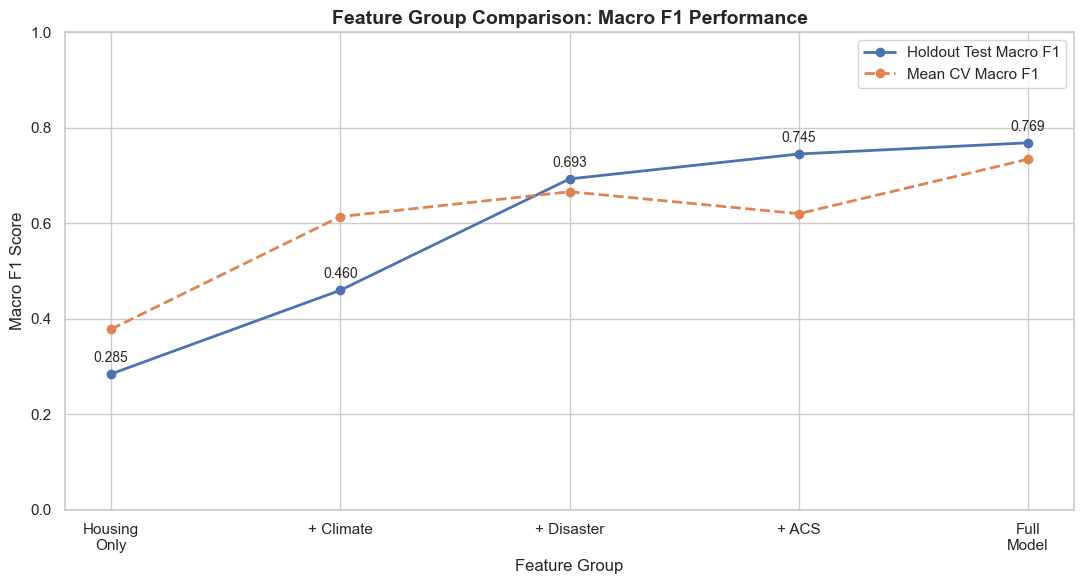

Figure saved to: ..\results\figures\feature_group_comparison\feature_group_macro_f1_curve.png


In [17]:
# ==================================================
# Step 17.1: Plot Feature Group Macro F1 Curve
# ==================================================

plot_data = feature_group_comparison.copy()

short_group_labels = [
    "Housing\nOnly",
    "+ Climate",
    "+ Disaster",
    "+ ACS",
    "Full\nModel"
]

x_positions = np.arange(len(plot_data))

plt.figure(figsize=(11, 6))

plt.plot(
    x_positions,
    plot_data["test_macro_f1"],
    marker="o",
    linewidth=2,
    label="Holdout Test Macro F1"
)

plt.plot(
    x_positions,
    plot_data["cv_macro_f1_mean"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Mean CV Macro F1"
)

for index, row in plot_data.iterrows():
    plt.text(
        index,
        row["test_macro_f1"] + 0.025,
        f"{row['test_macro_f1']:.3f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Feature Group Comparison: Macro F1 Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Group")
plt.ylabel("Macro F1 Score")
plt.xticks(x_positions, short_group_labels)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

figure_path = RESULTS_FIGURES / "feature_group_macro_f1_curve.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

The macro F1 performance curve shows that housing-only features provide weak classification performance, while each additional feature layer improves holdout performance. The largest visible gain occurs after adding disaster-history variables, and the Full Model achieves the strongest overall test macro F1. The difference between CV and holdout performance for some groups suggests that certain feature layers are more temporally stable than others, but the full multi-source model performs best overall.

### 17.2 Marginal Contribution by Added Feature Layer

This figure shows how much each added feature layer improves holdout macro F1 compared with the previous feature group.

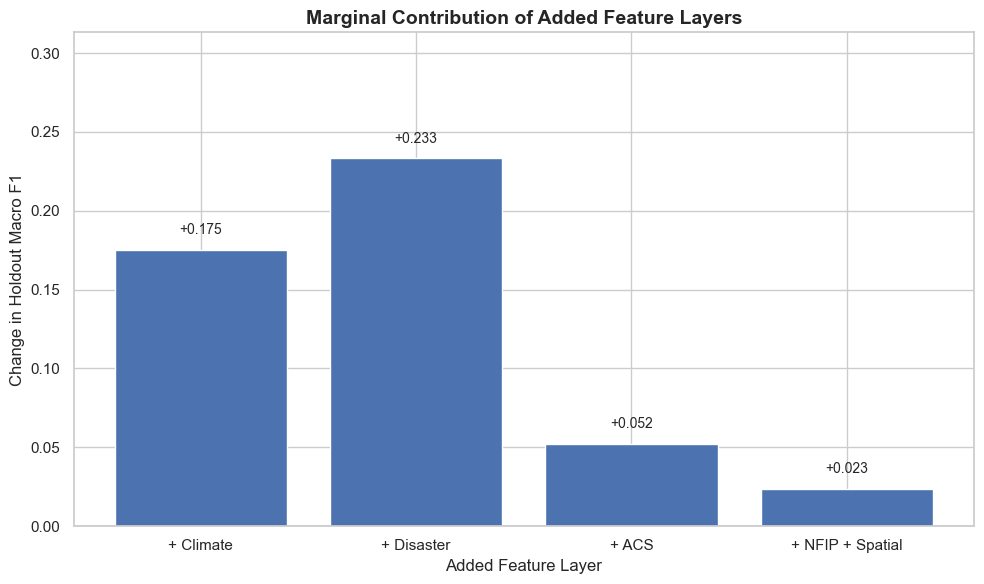

Figure saved to: ..\results\figures\feature_group_comparison\feature_group_marginal_contribution.png


In [18]:
# ==================================================
# Step 17.2: Plot Marginal Contribution to Test Macro F1
# ==================================================

plot_data = marginal_contribution.dropna(
    subset=["delta_test_macro_f1"]
).copy()

short_layer_labels = [
    "+ Climate",
    "+ Disaster",
    "+ ACS",
    "+ NFIP + Spatial"
]

x_positions = np.arange(len(plot_data))

plt.figure(figsize=(10, 6))

plt.bar(
    x_positions,
    plot_data["delta_test_macro_f1"]
)

for index, value in enumerate(plot_data["delta_test_macro_f1"]):
    plt.text(
        index,
        value + 0.01,
        f"+{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.axhline(0, linewidth=1)

plt.title(
    "Marginal Contribution of Added Feature Layers",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Added Feature Layer")
plt.ylabel("Change in Holdout Macro F1")
plt.xticks(x_positions, short_layer_labels)
plt.ylim(0, plot_data["delta_test_macro_f1"].max() + 0.08)
plt.tight_layout()

figure_path = RESULTS_FIGURES / "feature_group_marginal_contribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

The marginal contribution plot shows that each added feature layer improves holdout macro F1, but the gains are not equal. The largest improvement comes from adding disaster-history variables, suggesting that realized disaster burden is the strongest additional signal beyond housing and static climate exposure. Climate exposure also adds substantial value, while ACS, NFIP, and spatial features provide smaller but still positive improvements. This supports the use of a multi-source vulnerability framework rather than relying on housing-market indicators alone.

### 17.3 Class-Wise F1 by Feature Group

This figure compares how each feature group performs for Low, Medium, and High vulnerability classes.

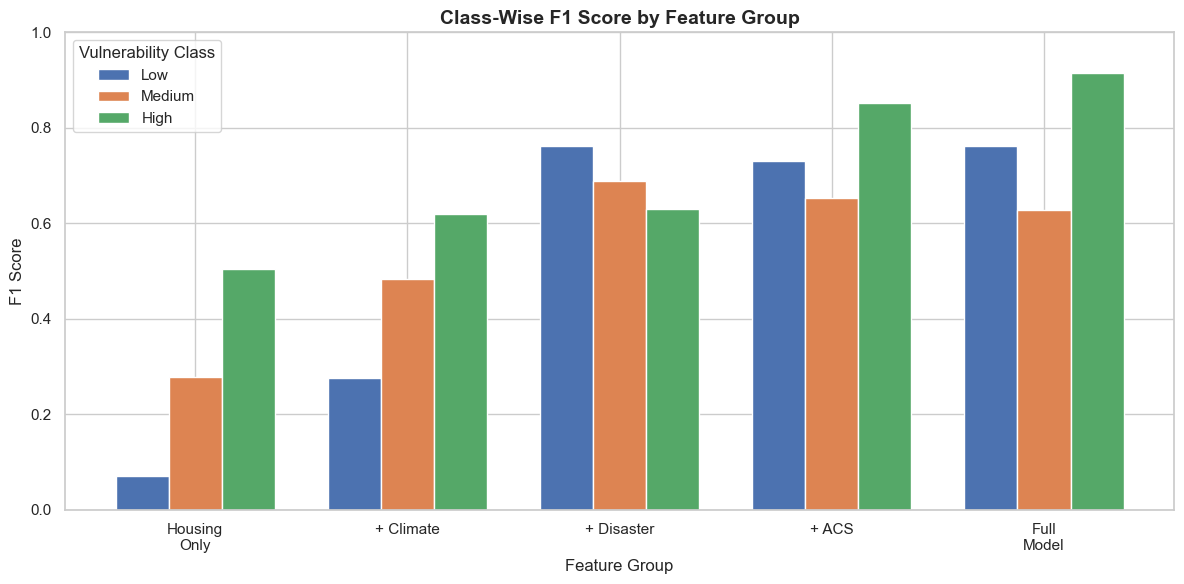

Figure saved to: ..\results\figures\feature_group_comparison\feature_group_classwise_f1.png


In [19]:
# ==================================================
# Step 17.3: Plot Class-Wise F1 by Feature Group
# ==================================================

plot_data = classwise_f1_pivot.copy()

short_group_labels = [
    "Housing\nOnly",
    "+ Climate",
    "+ Disaster",
    "+ ACS",
    "Full\nModel"
]

x_positions = np.arange(len(plot_data))
bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x_positions - bar_width,
    plot_data["Low"],
    width=bar_width,
    label="Low"
)

plt.bar(
    x_positions,
    plot_data["Medium"],
    width=bar_width,
    label="Medium"
)

plt.bar(
    x_positions + bar_width,
    plot_data["High"],
    width=bar_width,
    label="High"
)

plt.title(
    "Class-Wise F1 Score by Feature Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Group")
plt.ylabel("F1 Score")
plt.xticks(x_positions, short_group_labels)
plt.ylim(0, 1)
plt.legend(title="Vulnerability Class")
plt.tight_layout()

figure_path = RESULTS_FIGURES / "feature_group_classwise_f1.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### 17.4 Class-Wise Recall by Feature Group

This figure compares how well each feature group identifies actual Low, Medium, and High vulnerability cases.

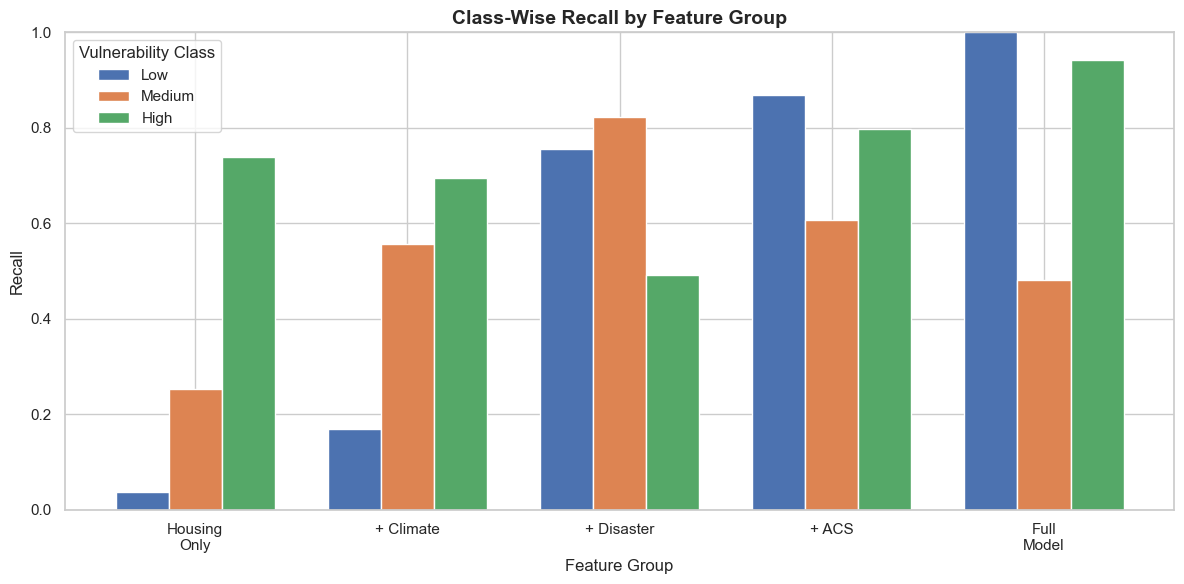

Figure saved to: ..\results\figures\feature_group_comparison\feature_group_classwise_recall.png


In [20]:
# ==================================================
# Step 17.4: Plot Class-Wise Recall by Feature Group
# ==================================================

plot_data = classwise_recall_pivot.copy()

short_group_labels = [
    "Housing\nOnly",
    "+ Climate",
    "+ Disaster",
    "+ ACS",
    "Full\nModel"
]

x_positions = np.arange(len(plot_data))
bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x_positions - bar_width,
    plot_data["Low"],
    width=bar_width,
    label="Low"
)

plt.bar(
    x_positions,
    plot_data["Medium"],
    width=bar_width,
    label="Medium"
)

plt.bar(
    x_positions + bar_width,
    plot_data["High"],
    width=bar_width,
    label="High"
)

plt.title(
    "Class-Wise Recall by Feature Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Group")
plt.ylabel("Recall")
plt.xticks(x_positions, short_group_labels)
plt.ylim(0, 1)
plt.legend(title="Vulnerability Class")
plt.tight_layout()

figure_path = RESULTS_FIGURES / "feature_group_classwise_recall.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")